In [1]:
import sys
sys.path.append('/Users/yulinli/Desktop/Exp/diffusion_policy')
from core.networks.diffusion import GaussianDiffusionPB
from core.networks.unet import TemporalUnet_WCond
from config.plane_test import PlaneTestConfig
import torch

In [2]:
config = PlaneTestConfig()
net = TemporalUnet_WCond(
            horizon=config.horizon,
            transition_dim=config.transition_dim,
            network_config=config.network_config
)
model = GaussianDiffusionPB(
    model=net,
    horizon=config.horizon,
    observation_dim=config.observation_dim,
    action_dim=config.action_dim,
    diff_config=config.diff_config
)

[TemporalUnet_WCond] concept_drop_prob: 0.1
[TemporalUnet_WCond] time_dim: 32
[TemporalUnet_WCond] construct ViT1D as wall loc encoder
self.vit1d_config: {'image_size': 8, 'patch_size': 4, 'channels': 1, 'num_classes': 32, 'dim': 512, 'depth': 6, 'heads': 8, 'mlp_dim': 1024, 'dropout': 0.1, 'emb_dropout': 0.1}
[TemporalUnet_WCond] self.wallLoc_encoder <class 'core.networks.vit.ViT'>
[Unet down_times] 100000.0 
[Luo self.train_apply_condition] True
[Luo self.set_cond_noise_to_0] False


In [3]:
checkpoint_path = 'checkpoints/checkpoint_epoch_9800.pt'  # 你的模型保存路径
ckpt = torch.load(checkpoint_path, map_location='cpu')
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

/var/folders/p3/v0zvzgdj3b96bkk4w12c23w80000gn/T/ipykernel_75130/3284808472.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_locati

GaussianDiffusionPB(
  (model): TemporalUnet_WCond(
    (time_mlp): Sequential(
      (0): SinusoidalPosEmb()
      (1): Linear(in_features=32, out_features=128, bias=True)
      (2): Mish()
      (3): Linear(in_features=128, out_features=32, bias=True)
    )
    (wallLoc_encoder): ViT(
      (to_patch_embedding): Sequential(
        (0): Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=4, p2=4)
        (1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (2): Linear(in_features=16, out_features=512, bias=True)
        (3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (transformer): Transformer(
        (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (layers): ModuleList(
          (0-5): 6 x ModuleList(
            (0): Attention(
              (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
              (attend): Softmax(dim=-1)
              (dropout): Dropou

In [4]:
cond = {
    0: torch.tensor([[2.0, 6.0]]),   # 起点
    -1: torch.tensor([[6.0, 6.0]])   # 终点
}
walls_loc = torch.zeros(1, 1, 8, 8)
with torch.no_grad():
    sampled_traj = model.conditional_sample(
        cond=cond,
        walls_loc=walls_loc,
        use_ddim=True  # or False
    ) 

conditional_sample shape: (1, 32, 2) walls_loc torch.Size([1, 1, 8, 8])
0 torch.Size([1, 2])
-1 torch.Size([1, 2])
Before repeat:
x torch.Size([1, 32, 2])
t torch.Size([1])
walls_loc torch.Size([1, 1, 8, 8])
After repeat:
x_2 torch.Size([2, 32, 2])
t_2 torch.Size([2])
walls_loc_2 torch.Size([2, 1, 8, 8])
Before repeat:
x torch.Size([1, 32, 2])
t torch.Size([1])
walls_loc torch.Size([1, 1, 8, 8])
After repeat:
x_2 torch.Size([2, 32, 2])
t_2 torch.Size([2])
walls_loc_2 torch.Size([2, 1, 8, 8])
Before repeat:
x torch.Size([1, 32, 2])
t torch.Size([1])
walls_loc torch.Size([1, 1, 8, 8])
After repeat:
x_2 torch.Size([2, 32, 2])
t_2 torch.Size([2])
walls_loc_2 torch.Size([2, 1, 8, 8])
Before repeat:
x torch.Size([1, 32, 2])
t torch.Size([1])
walls_loc torch.Size([1, 1, 8, 8])
After repeat:
x_2 torch.Size([2, 32, 2])
t_2 torch.Size([2])
walls_loc_2 torch.Size([2, 1, 8, 8])
Before repeat:
x torch.Size([1, 32, 2])
t torch.Size([1])
walls_loc torch.Size([1, 1, 8, 8])
After repeat:
x_2 torch.Size

In [5]:
import numpy as np
np.save('sampled_traj.npy', sampled_traj.cpu().numpy())

In [6]:
import matplotlib.pyplot as plt
def show(bounds, grid, path=None, raw_path=None, start=None, goal=None, figsize=(6, 6)):
    nx, ny = grid.shape
    cell_size = 1.0
    origin = bounds[:, 0]
    _, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.set_xlim(bounds[0])
    ax.set_ylim(bounds[1])
    ax.set_title("RRT on occupancy grid (pruning=%s)" % ("on" if path is not None else "off"))

    xs = np.arange(nx) * cell_size + origin[0]
    ys = np.arange(ny) * cell_size + origin[1]
    for ix in range(nx):
        for iy in range(ny):
            if grid[ix, iy]:
                rect = plt.Rectangle(
                    (xs[ix], ys[iy]),
                    cell_size,
                    cell_size,
                    color="gray",
                    alpha=0.5,
                )
                ax.add_patch(rect)

    def _draw(p, style, label):
        p = np.asarray(p)
        ax.plot(p[:, 0], p[:, 1], style, label=label)

    if raw_path is not None:
        _draw(raw_path, "r--", "raw")
    if path is not None:
        _draw(path, "b-", "pruned/opt")
        ax.plot(path[:, 0], path[:, 1], "bo", ms=3)
    ax.legend()
    plt.grid(True)
    plt.show()

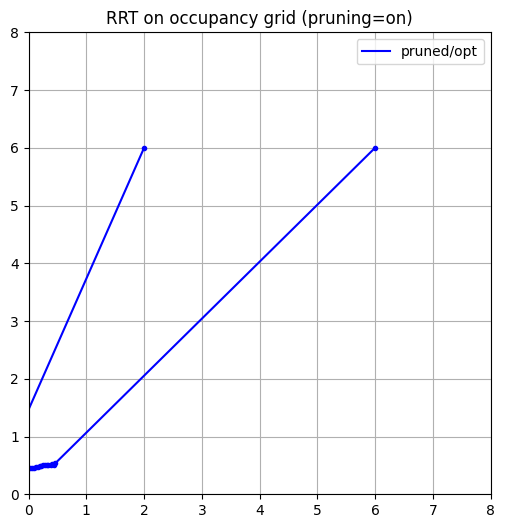

In [7]:
bounds = [(0.0, 8.0), (0.0, 8.0)]
bounds = np.array(bounds)
cell = 1
nx, ny = (int((b[1] - b[0]) / cell) for b in bounds)
grid = np.zeros((nx, ny), dtype=bool)
show(bounds, grid, path=sampled_traj[0, :, :2].cpu().numpy(), start=cond[0].cpu().numpy()[0], goal=cond[-1].cpu().numpy()[0])
